# 1.1
1. List three real networks
    - Train networks. The nodes are train stations and the edges are train connections. The network is undirected, as trains go both ways (I would expect that to always be true, I wonder if there are counterexamples). It should be a weighted network, since train connections have different lengths. The weights could represent distance or time.
    - Discord friends. The nodes are people (or discord acccounts, I suppose), and the edges are friendships. The network is undirected, as friendships are symmetrical, and unweighted, as one friendship is equivalent to any other.
    - Chess board states. The nodes are unique board states, and the edges connect board states that are reachable from each other in one move. The network is undirected, as many moves are not reversible (but some are), and unweighted, as we only want to think about one move at a time (weight 1).
2. Pick a network you personally care about.

    My network is heavy metal musicians active in the 70s and 80s. The nodes are individual musicians, and the edges connect musicians who have featured on songs together. I would guess the scale is a few thousand musicians, certainly less than 100,000, and maybe less than 10,000. Data about well known bands is available (could even be scraped from Wikipedia), but many small bands might not have left much data behind. It *could* change over time if we expanded the network to include *all* heavy metal musicians, as new bands are being created all the time. I care about this network because I love heavy metal.
3. Describe a network that can be cast in two different ways.

    The musician network. You could model it as which musicians have played together, and you get a network which large connected components that evolve over time. You could also model which musicians are currently in a band together, and you get a network with only small, temporary islands of (generally) 3-6 people.

# 1.2
1. Ask your favorite LLM 10 specific questions about the network you chose.

    I asked questions about the average degree of the network, who would be top 10 most connected musicians, and I asked it to list every musician who has played with Ozzy Osbourne.
2. Grade every answer against a source you trust.

    The LLM gave sensible answers to general questions about average degree (most musicians have a low degree, as most bands only change lineups a handful of times). However, when I started asking more specific questions, it started getting things wrong. For example, it claimed that Ozzy Osbourne and Dio played together in Black Sabbath, but Dio replaced Osbourne as the lead singer of the band, and the LLM was not able to name a song that credited them both when I asked for evidence.
3. What would you let the LLM do unsupervised, and what would you also verify?

    I would verify most questions, but especially questions about specific details, i.e. which are the top 10 most connected nodes, what is the shortest path between two nodes, how many connections does this specific node have, etc. as the LLM was prone to making mistakes here. Generally, I would ask the AI to write code to extract answers from the raw data, and then justify the methodology, and check that the choices make sense.

In [15]:
import pandas as pd, networkx as nx

nodes = pd.read_csv("data/week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: TSVs never quote, but blurbs may contain "quotes"
edges = pd.read_csv("data/week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)
G.add_edges_from(edges.itertuples(index=False))

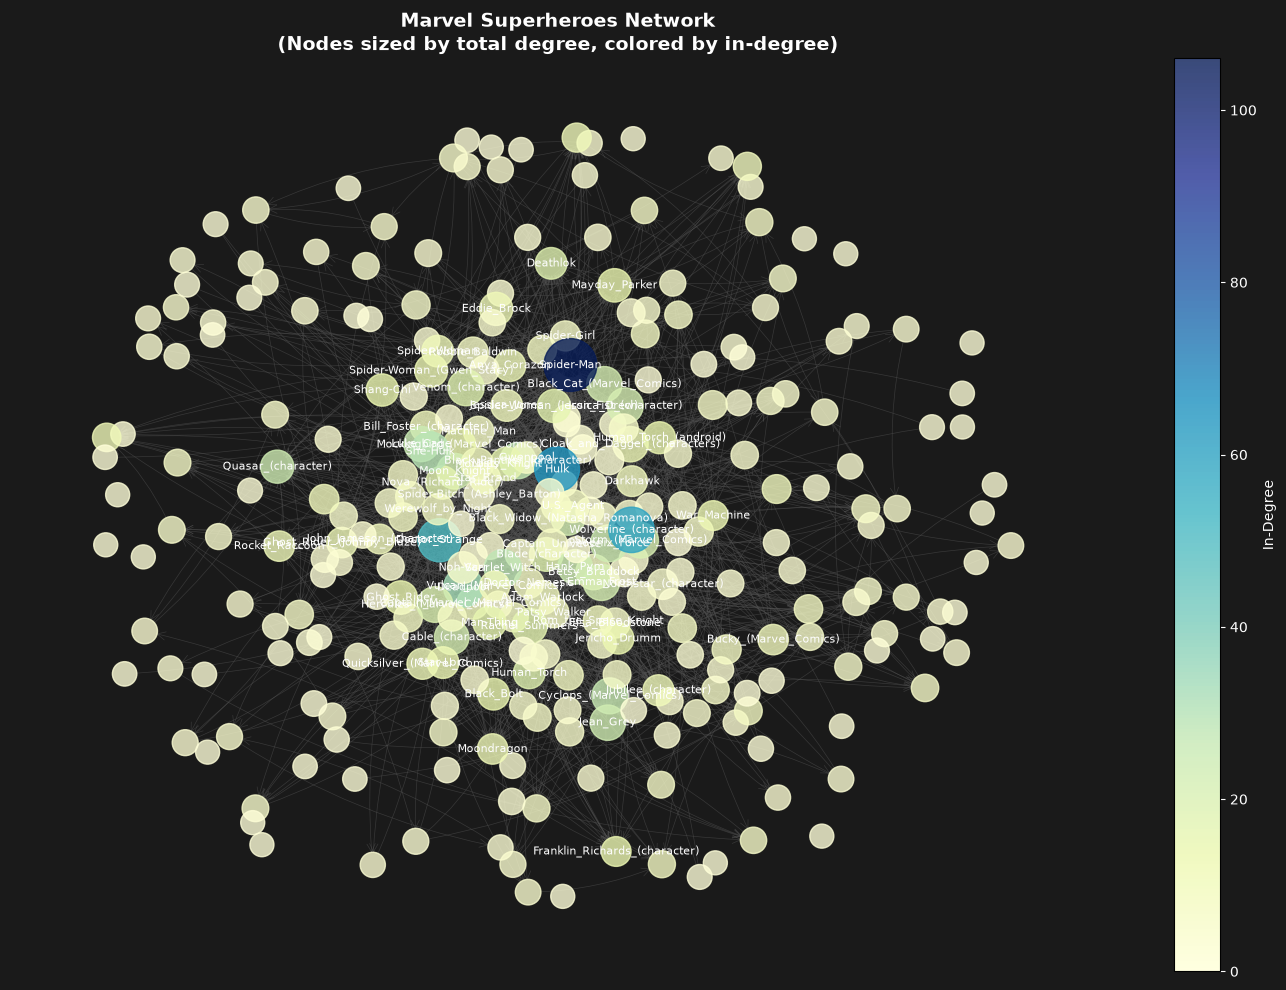

Network Statistics:
Number of nodes: 303
Number of edges: 1784
Network density: 0.0195
Average in-degree: 5.89
Average out-degree: 5.89

Most connected node: Spider-Man
Total degree: 115


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with the network visualization and dark background
fig, ax = plt.subplots(figsize=(14, 10), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')

# Use spring layout for better node positioning
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Find the most connected node (by total degree)
most_connected = max(G.nodes(), key=lambda node: G.in_degree(node) + G.out_degree(node))
most_connected_pos = pos[most_connected]

# Center the layout around the most connected node
for node in pos:
    pos[node] = pos[node] - most_connected_pos

# Calculate node sizes based on degree (in-degree + out-degree)
node_sizes = [300 + 10 * (G.in_degree(node) + G.out_degree(node)) for node in G.nodes()]

# Draw edges with arrows (indicating direction)
nx.draw_networkx_edges(G, pos, edge_color='#555555', arrows=True, 
                       arrowsize=15, arrowstyle='->', width=0.5, 
                       connectionstyle='arc3,rad=0.1', ax=ax, alpha=0.5)

# Draw nodes colored by in-degree with light gradient
node_colors = [G.in_degree(node) for node in G.nodes()]
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                               node_color=node_colors, cmap='YlGnBu',
                               ax=ax, alpha=0.8)

# Add labels for highly connected nodes (degree > threshold)
threshold = np.percentile([G.in_degree(node) + G.out_degree(node) for node in G.nodes()], 75)
labels = {node: node for node in G.nodes() if G.in_degree(node) + G.out_degree(node) > threshold}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_color='white', ax=ax)

# Add colorbar
cbar = plt.colorbar(nodes, ax=ax, label='In-Degree')
cbar.ax.tick_params(colors='white')
cbar.ax.yaxis.label.set_color('white')

ax.set_title('Marvel Superheroes Network\n(Nodes sized by total degree, colored by in-degree)', 
             fontsize=14, fontweight='bold', color='white')
ax.axis('off')
plt.tight_layout()
plt.show()

# Print basic network statistics
print(f"Network Statistics:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Network density: {nx.density(G):.4f}")
print(f"Average in-degree: {sum(dict(G.in_degree()).values()) / G.number_of_nodes():.2f}")
print(f"Average out-degree: {sum(dict(G.out_degree()).values()) / G.number_of_nodes():.2f}")
print(f"\nMost connected node: {most_connected}")
print(f"Total degree: {G.in_degree(most_connected) + G.out_degree(most_connected)}")